In [2]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)
print(torch.cuda.is_available())

2.8.0+cpu
0.23.0+cpu
False


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# -------------------------
# 1. Paths
# -------------------------
train_dir = r"C:\Users\A77\Downloads\archive\Skin cancer ISIC The International Skin Imaging Collaboration\Train"
test_dir  = r"C:\Users\A77\Downloads\archive\Skin cancer ISIC The International Skin Imaging Collaboration\Test"


In [4]:

# -------------------------
# 2. Transforms (important for deep learning)
# -------------------------
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    # good for medical dataset as position doesnt matter so left<-> right direction changes 
    transforms.RandomHorizontalFlip(),  
    # change in angles from -10 to +10 degree to better tain model
    transforms.RandomRotation(10),
    # converting into tensors 
    transforms.ToTensor(),
    # 0->-1   0.5 ->0  1->+1
    transforms.Normalize([0.5], [0.5])  # simple normalization
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


In [5]:

# -------------------------
# 3. Load datasets
# -------------------------


# it works like this when image classification is present in form of folders
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=test_dir, transform=test_transforms)

# -------------------------
# 4. Create DataLoaders
# -------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# -------------------------
# 5. Check
# -------------------------
print("Classes:", train_dataset.classes)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Train samples: 2239
Test samples: 118


In [29]:
images, labels = next(iter(train_loader))
images[0].shape
# labels[0]

torch.Size([3, 224, 224])

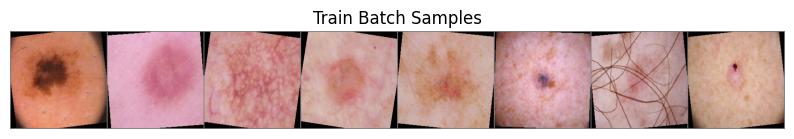

In [27]:
import matplotlib.pyplot as plt
import torchvision

# make a grid of images
img_grid = torchvision.utils.make_grid(images[:8])

# unnormalize (because we used Normalize earlier)
img_grid = img_grid / 2 + 0.5

plt.figure(figsize=(10, 5))
plt.imshow(img_grid.permute(1, 2, 0))
plt.title("Train Batch Samples")
plt.axis("off")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 9)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 224 → 112
        x = self.pool(F.relu(self.conv2(x)))  # 112 → 56
        x = self.pool(F.relu(self.conv3(x)))  # 56 → 28

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


model = SimpleCNN()

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [31]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 1

for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/20], Loss: 0.2627
Epoch [2/20], Loss: 0.2481
Epoch [3/20], Loss: 0.2515
Epoch [4/20], Loss: 0.2443
Epoch [5/20], Loss: 0.2522
Epoch [6/20], Loss: 0.2551


In [42]:
torch.save(model.state_dict(), "isic_cnn_epoch22.pth")

In [35]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        # images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 33.898305084745765


In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        # images = images.to(device)
        # labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [38]:
cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[ 0  0  0  0 15  1  0  0  0]
 [ 2  6  3  1  0  2  0  2  0]
 [ 0  4  4  3  2  2  0  1  0]
 [ 0  0  0  1 11  4  0  0  0]
 [ 0  0  0  1 15  0  0  0  0]
 [ 1  2  0  2  0  9  0  2  0]
 [ 0  0  0  3  0  0  0  0  0]
 [ 0  3  0  4  1  5  0  3  0]
 [ 0  1  0  0  0  0  0  0  2]]


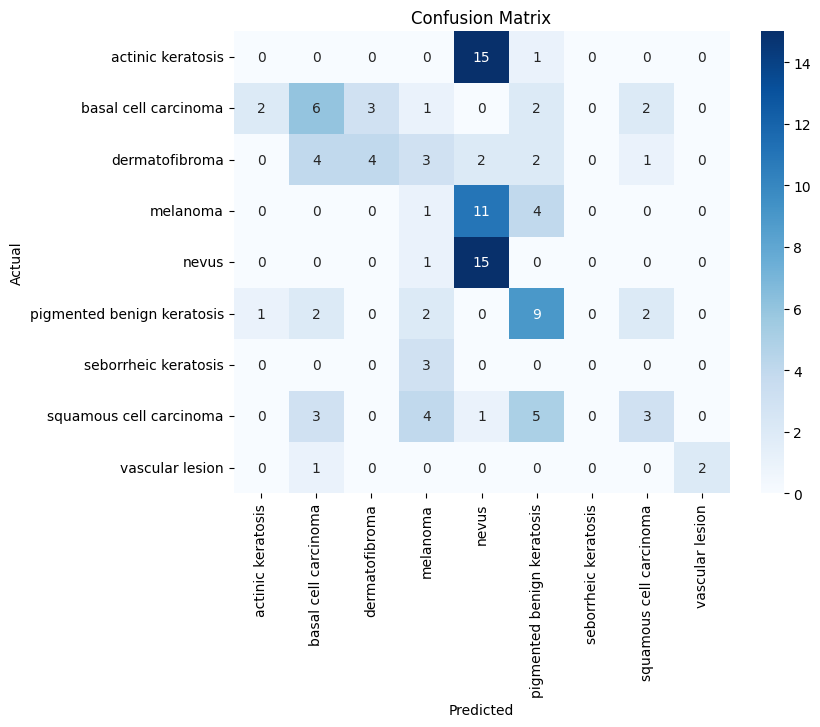

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.38      0.38      0.38        16
            dermatofibroma       0.57      0.25      0.35        16
                  melanoma       0.07      0.06      0.06        16
                     nevus       0.34      0.94      0.50        16
pigmented benign keratosis       0.39      0.56      0.46        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.38      0.19      0.25        16
           vascular lesion       1.00      0.67      0.80         3

                  accuracy                           0.34       118
                 macro avg       0.35      0.34      0.31       118
              weighted avg       0.31      0.34      0.29       118



c:\Users\A7517\pytorch_projects\venv_isic\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\A7517\pytorch_projects\venv_isic\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\A7517\pytorch_projects\venv_isic\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

In [ ]:
from collections import Counter

# count class indices
class_counts = Counter(train_dataset.targets)

for class_index, count in class_counts.items():
    class_name = train_dataset.classes[class_index]
    print(f"{class_name}: {count}")

actinic keratosis: 114
basal cell carcinoma: 376
dermatofibroma: 95
melanoma: 438
nevus: 357
pigmented benign keratosis: 462
seborrheic keratosis: 77
squamous cell carcinoma: 181
vascular lesion: 139


USING PRETRAINED CNN MODELS NOW LIKE RESNET 18(TRANSFER LEARNING)

In [22]:
from torchvision import transforms

train_transforms_resnet = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms_resnet = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
#train_loader 

# -------------------------
# 3. Load datasets
# -------------------------


# it works like this when image classification is present in form of folders
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms_resnet)
test_dataset  = datasets.ImageFolder(root=test_dir, transform=test_transforms_resnet)

# -------------------------
# 4. Create DataLoaders
# -------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# -------------------------
# 5. Check
# -------------------------
print("Classes:", train_dataset.classes)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Train samples: 2239
Test samples: 118


In [24]:
#RESNET 18 MODEL

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

modelnet = models.resnet18(weights='IMAGENET1K_V1')

# Replace final layer
num_features = modelnet.fc.in_features

modelnet.fc = nn.Linear(num_features, 9)

modelnet = modelnet.to(device)

cpu


In [25]:
modelnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [26]:
# 3. Weighted loss (VERY IMPORTANT)

# Your dataset is imbalanced.

# Use weighted loss:
from collections import Counter

class_counts = Counter(train_dataset.targets)
print(class_counts)

total_samples = sum(class_counts.values())

weights = []

for i in range(len(train_dataset.classes)):
    weights.append(total_samples / class_counts[i])

weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

Counter({5: 462, 3: 438, 1: 376, 4: 357, 7: 181, 8: 139, 0: 114, 2: 95, 6: 77})


In [27]:
# 4. Optimizer

# Use lower learning rate:
import torch.optim as optim

optimizer = optim.Adam(modelnet.parameters(), lr=0.0001)

In [28]:
epochs = 10

for epoch in range(epochs):

    modelnet.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = modelnet(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10] Loss: 1.5258
Epoch [2/10] Loss: 0.9953
Epoch [3/10] Loss: 0.8119
Epoch [4/10] Loss: 0.7214
Epoch [5/10] Loss: 0.6664
Epoch [6/10] Loss: 0.5823
Epoch [7/10] Loss: 0.5201
Epoch [8/10] Loss: 0.5285
Epoch [9/10] Loss: 0.4922
Epoch [10/10] Loss: 0.4676


In [30]:
model.eval()

correct = 0
total = 0

val_loss = 0.0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = modelnet(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Loss: {val_loss/len(test_loader):.4f}")
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Loss: 2.8007
Validation Accuracy: 33.05%
